# Hate Speech Detection - Exploratory Data Analysis (EDA)
5CCSACCA Cloud Computing for Artificial Intelligence  

In [5]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os
import numpy as np

# Set plot style
sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the Raw Data

First, we'll load the Davidson Hate Speech dataset and Jigsaw dataset into a Pandas DataFrame.


In [6]:
import os
import pandas as pd

#Define paths to your datasets
davidson_path = os.path.join('..', 'data', 'raw_data', 'labeled_data.csv')
jigsaw_path = os.path.join('..', 'data', 'raw_data', 'train.csv')  # Replace 'train.csv' if your Jigsaw file has a different name

df_davidson = pd.read_csv(davidson_path)
df_jigsaw = pd.read_csv(jigsaw_path)

# Display the first few rows
print("Davidson Dataset - First 5 Rows:")
display(df_davidson.head())

print("\nJigsaw Toxic Comment Dataset - First 5 Rows:")
display(df_jigsaw.head())


Davidson Dataset - First 5 Rows:


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



Jigsaw Toxic Comment Dataset - First 5 Rows:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 2. Understand the Data Structure

Let's get an overview of the dataset, including data types and missing values.

In [7]:
# Davidson dataset information
print("Davidson Dataset Info:")
print(df_davidson.info())
print("\nDavidson Dataset Description:")
print(df_davidson.describe())

Davidson Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

Davidson Dataset Description:
         Unnamed: 0         count   hate_speech  offensive_language  \
count  24783.000000  24783.000000  24783.000000        24783.000000   
mean   12681.192027      3.243473      0.280515            2.413711   
std     7299.553863      0.883060      0.631851            1.399459   
min        0.000000      3.000000      0.000000            0.000000

In [8]:
# Jigsaw dataset information
print("\nJigsaw Toxic Comment Dataset Info:")
print(df_jigsaw.info())
print("\nJigsaw Toxic Comment Dataset Description:")
print(df_jigsaw.describe())


Jigsaw Toxic Comment Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

Jigsaw Toxic Comment Dataset Description:
               toxic   severe_toxic        obscene         threat  \
count  159571.000000  159571.000000  159571.000000  159571.000000   
mean        0.095844       0.009996       0.052948       0.002996   
std         0.294379       0.099477       0.223931       0.054650   
min         0.000000       0.000000     

In [9]:
# Missing values in Davidson dataset
print("Missing Values in Davidson Dataset:")
print(df_davidson.isnull().sum())

# Missing values in Jigsaw dataset
print("\nMissing Values in Jigsaw Toxic Comment Dataset:")
print(df_jigsaw.isnull().sum())

Missing Values in Davidson Dataset:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Missing Values in Jigsaw Toxic Comment Dataset:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


## 3. Analyze Class Distribution

Visualize the distribution of labels to identify any class imbalances.

Davidson Dataset Label Distribution:
class
1    19190
2     4163
0     1430
Name: count, dtype: int64


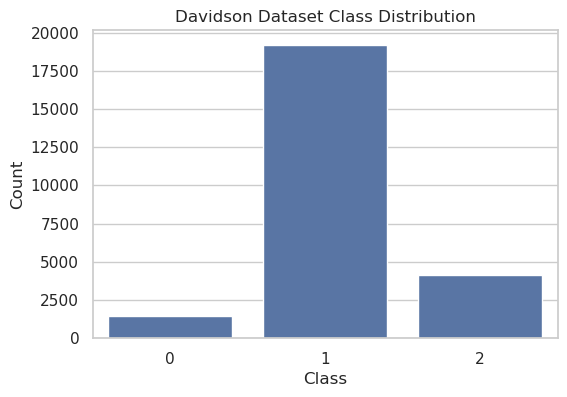


Jigsaw Toxic Comment Dataset Label Distribution:
toxic
0    144277
1     15294
Name: count, dtype: int64


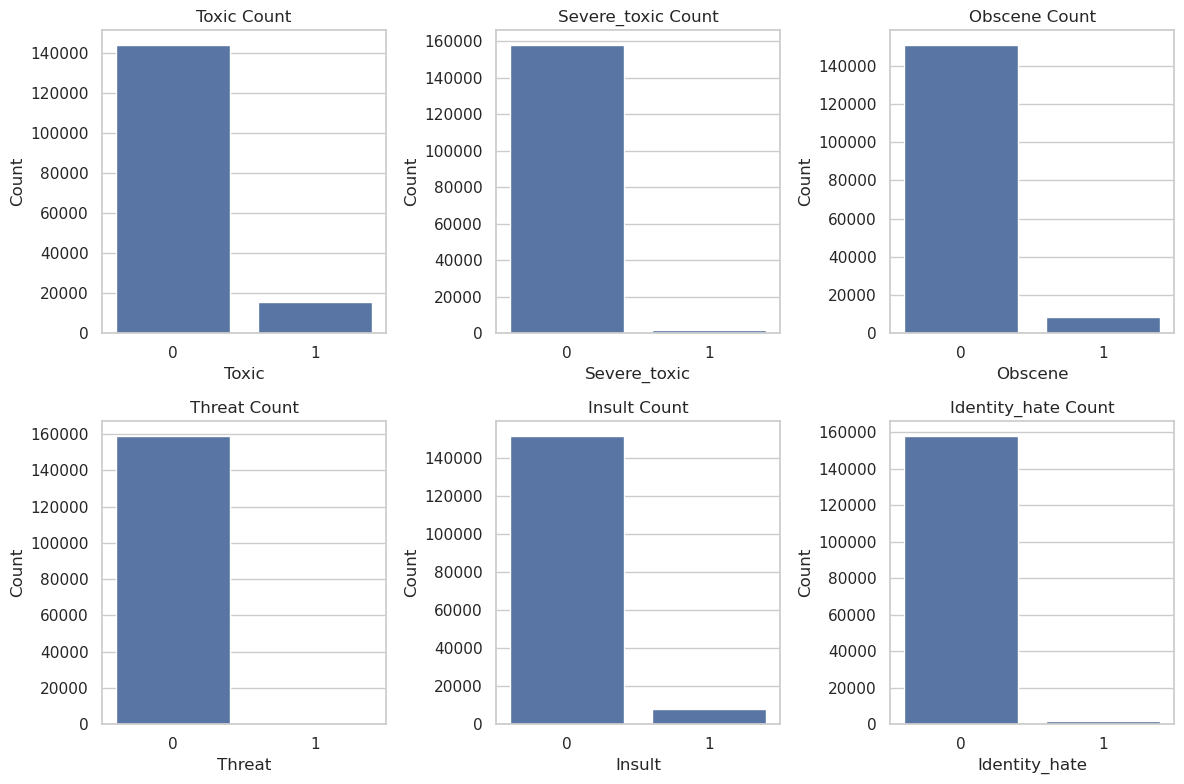

In [10]:
# Davidson dataset label distribution
print("Davidson Dataset Label Distribution:")
print(df_davidson['class'].value_counts())

# Plotting Davidson label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df_davidson)
plt.title('Davidson Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Jigsaw dataset label distribution
print("\nJigsaw Toxic Comment Dataset Label Distribution:")
print(df_jigsaw['toxic'].value_counts())

# Since Jigsaw has multiple labels, visualize each
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
plt.figure(figsize=(12,8))
for i, label in enumerate(labels, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=label, data=df_jigsaw)
    plt.title(f'{label.capitalize()} Count')
    plt.xlabel(label.capitalize())
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
# Summary statistics for Davidson dataset
print("Davidson Dataset Summary Statistics:")
print(df_davidson.describe(include='all'))

Davidson Dataset Summary Statistics:
          Unnamed: 0         count   hate_speech  offensive_language  \
count   24783.000000  24783.000000  24783.000000        24783.000000   
unique           NaN           NaN           NaN                 NaN   
top              NaN           NaN           NaN                 NaN   
freq             NaN           NaN           NaN                 NaN   
mean    12681.192027      3.243473      0.280515            2.413711   
std      7299.553863      0.883060      0.631851            1.399459   
min         0.000000      3.000000      0.000000            0.000000   
25%      6372.500000      3.000000      0.000000            2.000000   
50%     12703.000000      3.000000      0.000000            3.000000   
75%     18995.500000      3.000000      0.000000            3.000000   
max     25296.000000      9.000000      7.000000            9.000000   

             neither         class  \
count   24783.000000  24783.000000   
unique           NaN  

In [12]:
# Summary statistics for Jigsaw dataset
print("\nJigsaw Toxic Comment Dataset Summary Statistics:")
print(df_jigsaw.describe(include='all'))


Jigsaw Toxic Comment Dataset Summary Statistics:
                      id                                       comment_text  \
count             159571                                             159571   
unique            159571                                             159571   
top     0000997932d777bf  Explanation\nWhy the edits made under my usern...   
freq                   1                                                  1   
mean                 NaN                                                NaN   
std                  NaN                                                NaN   
min                  NaN                                                NaN   
25%                  NaN                                                NaN   
50%                  NaN                                                NaN   
75%                  NaN                                                NaN   
max                  NaN                                                NaN   

 

In [13]:
# Check duplicates in Davidson dataset
duplicate_davidson = df_davidson.duplicated().sum()
print(f"Number of duplicate rows in Davidson dataset: {duplicate_davidson}")

# Check duplicates in Jigsaw dataset
duplicate_jigsaw = df_jigsaw.duplicated().sum()
print(f"Number of duplicate rows in Jigsaw dataset: {duplicate_jigsaw}")

Number of duplicate rows in Davidson dataset: 0
Number of duplicate rows in Jigsaw dataset: 0


## 4. Text Data Insights

### 4.1 Text Length Analysis

Understanding the distribution of text lengths helps in deciding preprocessing steps like truncation.

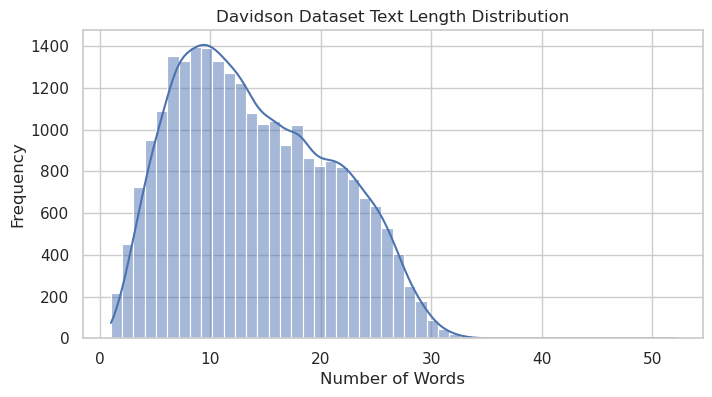

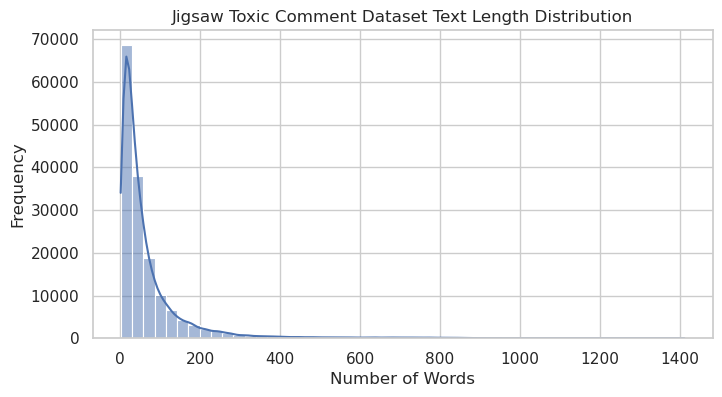

In [14]:
# Function to calculate text length
def text_length(text):
    return len(str(text).split())

# Add text length columns
df_davidson['text_length'] = df_davidson['tweet'].apply(text_length)
df_jigsaw['text_length'] = df_jigsaw['comment_text'].apply(text_length)

# Plot text length distribution for Davidson
plt.figure(figsize=(8,4))
sns.histplot(df_davidson['text_length'], bins=50, kde=True)
plt.title('Davidson Dataset Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Plot text length distribution for Jigsaw
plt.figure(figsize=(8,4))
sns.histplot(df_jigsaw['text_length'], bins=50, kde=True)
plt.title('Jigsaw Toxic Comment Dataset Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


## 6. Summary of EDA Findings

- **Class Distribution:** Their seems to be a lack of hate speech count. While their is a sufficient number of offensive and neutral.
- **Text Length:** The jigsaw dataset seems to be considerably larger in size per text which may require truncation.
- **Duplicates:** No duplicates seem to arrize
- **Missing Values:** No missing values
